# Clinical NLP Pipeline — End-to-End Demo

**Predicting 30-Day Hospital Readmission from Discharge Summaries**

This notebook runs the full pipeline:
1. **Data Generation & Loading** — Synthetic MIMIC-IV-style clinical data
2. **Preprocessing** — Clinical text cleaning, tokenization, phrase detection
3. **Topic Modeling** — LDA topic discovery on discharge notes
4. **Feature Engineering** — TF-IDF, topic distributions, structured features, text statistics
5. **Prediction** — Logistic Regression, Random Forest, XGBoost, LightGBM
6. **Fairness Audit** — Disparity analysis across gender, insurance, age group
7. **Visualization** — Publication-quality figures

In [1]:
import sys, os, logging, warnings
from pathlib import Path

# Project root setup
PROJECT_ROOT = Path(os.getcwd()).parent if "notebooks" in os.getcwd() else Path(os.getcwd())
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

# Logging & warnings
logging.basicConfig(level=logging.INFO, format="%(asctime)s — %(levelname)s — %(message)s")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import yaml
import numpy as np
import pandas as pd

with open("config/config.yaml") as f:
    config = yaml.safe_load(f)

print(f"Project root: {PROJECT_ROOT}")
print("Config loaded successfully.")

2026-04-11 18:19:23,300 — INFO — NumExpr defaulting to 8 threads.


Project root: c:\Users\USER\Desktop\AkashGroup\ClinicalNLP
Config loaded successfully.


## 1. Data Generation & Loading

Generate synthetic clinical data (patients, admissions, discharge notes) mimicking the MIMIC-IV schema, then load and merge into a single analysis-ready DataFrame.

In [2]:
from src.generate_synthetic_data import run as generate_data
from src.data_loader import load_all, get_data_summary

# Generate synthetic data (200 patients -> ~300+ notes)
generate_data(output_dir="data", n_patients=200)

# Load & merge all tables
df = load_all(config, use_synthetic=True)
summary = get_data_summary(df)

print(f"\nDataset shape: {df.shape}")
df.head(3)

2026-04-11 18:19:25,078 — INFO — Generating 200 synthetic patients...
2026-04-11 18:19:25,116 — INFO — Generating admissions with 18% readmission rate...


2026-04-11 18:19:25,657 — INFO — Admissions generated: 332 rows
2026-04-11 18:19:25,659 — INFO — Generating synthetic discharge notes...
2026-04-11 18:19:26,133 — INFO — Discharge notes generated: 332 rows
2026-04-11 18:19:26,211 — INFO — Saved patients (200), admissions (332), notes (332)
2026-04-11 18:19:26,213 — INFO — Readmission rate (eligible): 15.9%
2026-04-11 18:19:26,217 — INFO — Files saved to: C:\Users\USER\Desktop\AkashGroup\ClinicalNLP\data
2026-04-11 18:19:26,219 — INFO — Loading discharge notes from data\synthetic_discharge.csv ...
2026-04-11 18:19:26,306 — INFO — Discharge summaries found: 332
2026-04-11 18:19:26,314 — INFO — Loading admissions from data\synthetic_admissions.csv ...
2026-04-11 18:19:26,356 — INFO — Admissions loaded: 332 rows
2026-04-11 18:19:26,358 — INFO — Loading patients from data\synthetic_patients.csv ...
2026-04-11 18:19:26,380 — INFO — Patients loaded: 200 rows
2026-04-11 18:19:26,380 — INFO — Merging notes + admissions + patients ...
2026-04-11

--------------------------------------------------
DATASET SUMMARY
--------------------------------------------------
  Total notes          : 332
  Unique patients      : 200
  Unique admissions    : 332
  Readmission rate     : 15.9%
  Avg note length      : 420 words

  Gender distribution  : {'M': 180, 'F': 152}
  Age (mean/median)    : 64.3 / 70.0 yrs  [19–89]
  Age groups           : {'65+': 201, '40-65': 95, '<40': 36}
  Insurance types      : {'Medicare': 141, 'Other': 110, 'Medicaid': 81}
--------------------------------------------------

Dataset shape: (332, 28)


,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,text,admittime,dischtime,...,edouttime,hospital_expire_flag,readmission_30day,gender,anchor_age,anchor_year,anchor_year_group,dod,los_days,age_group
0,30000000,10000000,20000000,Discharge summary,1,2111-10-12 15:56:19,2111-10-12 15:56:19,Admission Date: ___\nDischarge Date: ___\nDate...,2111-10-06 15:56:19,2111-10-12 15:56:19,...,2111-10-06 15:56:19,0,0,M,75,2108,2106-2108,NaN,6.0,65+
1,30000001,10000000,20000001,Discharge summary,1,2112-09-22 15:56:19,2112-09-22 15:56:19,Admission Date: ___\nDischarge Date: ___\nDate...,2112-09-16 15:56:19,2112-09-22 15:56:19,...,2112-09-16 15:56:19,0,1,M,75,2108,2106-2108,NaN,6.0,65+
2,30000002,10000000,20000002,Discharge summary,1,2112-10-17 15:56:19,2112-10-17 15:56:19,Admission Date: ___\nDischarge Date: ___\nDate...,2112-10-10 15:56:19,2112-10-17 15:56:19,...,2112-10-10 15:56:19,0,-1,M,75,2108,2106-2108,NaN,7.0,65+


## 2. Preprocessing

Clean clinical text (remove PHI patterns, dates, special characters), tokenize with NLTK, and prepare documents for topic modeling and feature extraction.

In [3]:
from src.preprocess import build_preprocessing_pipeline

processed = build_preprocessing_pipeline(df, config=config, use_scispacy=False, use_phrases=False)

print(f"Processed shape: {processed.shape}")
print(f"Avg tokens per note: {processed['num_tokens'].mean():.1f}")
print(f"\nSample cleaned text (first 200 chars):")
print(processed["cleaned_text"].iloc[0][:200])
print(f"\nSample tokens: {processed['tokens'].iloc[0][:15]}")

2026-04-11 18:19:26,515 — INFO — Step 1/4 — removing unwanted sections from 332 notes ...
2026-04-11 18:19:26,600 — INFO — Step 2/4 — cleaning text ...
2026-04-11 18:19:26,953 — INFO — Filtered 0 notes outside length bounds — 332 remaining
2026-04-11 18:19:26,955 — INFO — Step 3/4 — tokenizing 332 notes (use_scispacy=False) ...
2026-04-11 18:19:49,622 — INFO — Downloading NLTK resource: wordnet
2026-04-11 18:19:50,886 — INFO — Downloading NLTK resource: averaged_perceptron_tagger
2026-04-11 18:20:05,089 — INFO — Loaded spacy model: en_core_web_sm (parser/ner disabled)
2026-04-11 18:20:24,244 — INFO — Step 4/4 — skipping phrase detection.
2026-04-11 18:20:24,259 — INFO — Preprocessing complete — vocab size: 809, avg tokens/doc: 197.3


Processed shape: (332, 31)
Avg tokens per note: 197.3

Sample cleaned text (first 200 chars):
admission date: 
discharge date: 
date of birth: 
sex: m
service: medicine
allergies: no known allergies
attending: md

chief complaint:
aki

history of present illness:
the patient is a 75-year-old m

Sample tokens: ['birth', 'sex', 'service', 'medicine', 'allergy', 'know', 'allergy', 'attend', 'md', 'chief', 'complaint', 'aki', 'present', 'illness', 'male']


## 2.5 Clinical Embeddings (ClinicalBERT)

Generate dense 768-dimensional embeddings from discharge notes using [Bio_ClinicalBERT](https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT), a BERT model pre-trained on clinical text from MIMIC-III. Long notes are handled via sliding-window chunking with mean pooling. Optionally reduced to 50 dims via PCA for use with classical ML models.

In [4]:
from src.embeddings import embed_texts

# Use cleaned text for embeddings (preserves more semantic content than tokens)
emb_cfg = config.get("embeddings", {})
texts_for_embedding = processed["cleaned_text"].tolist()

print(f"Generating clinical embeddings for {len(texts_for_embedding)} notes ...")
print(f"  Model: {emb_cfg.get('model_name', 'clinicalbert')}")
print(f"  Pooling: {emb_cfg.get('pooling', 'mean')}")
print(f"  Device: {emb_cfg.get('device', 'auto-detect')}")

embedding_matrix, emb_metadata = embed_texts(
    texts_for_embedding,
    model_name=emb_cfg.get("model_name", "clinicalbert"),
    pooling=emb_cfg.get("pooling", "mean"),
    max_length=emb_cfg.get("max_length", 512),
    stride=emb_cfg.get("stride", 256),
    device=emb_cfg.get("device", None),
)

print(f"\nEmbedding matrix shape: {embedding_matrix.shape}")
print(f"  Hidden size: {emb_metadata['hidden_size']}")
print(f"  Chunked documents: {emb_metadata['n_chunked']}/{emb_metadata['n_documents']}")
print(f"  Device used: {emb_metadata['device']}")

2026-04-11 18:21:11,273 — INFO — Loading embedding model: clinicalbert → emilyalsentzer/Bio_ClinicalBERT (device=cpu)


Generating clinical embeddings for 332 notes ...
  Model: clinicalbert
  Pooling: mean
  Device: None


2026-04-11 18:21:12,023 — INFO — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-11 18:21:12,025 — WARNING — Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-04-11 18:21:12,210 — INFO — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/emilyalsentzer/Bio_ClinicalBERT/d5892b39a4adaed74b92212a44081509db72f87b/config.json "HTTP/1.1 200 OK"
2026-04-11 18:21:12,715 — INFO — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/main/tokenizer_config.json "HTTP/1.1 404 Not Found"
2026-04-11 18:21:13,094 — INFO — HTTP Request: HEAD https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT/resolve/main/tokenizer_config.json "HTTP/1.1 404 Not Found"
2026-04-11 18:21:13,441 — INFO — HTTP Request: GET https://huggingface.co/api/models/emilyalsentzer/Bio_ClinicalBERT/tree/m

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-04-11 18:21:17,872 — INFO — HTTP Request: GET https://huggingface.co/api/models/emilyalsentzer/Bio_ClinicalBERT/discussions?p=0 "HTTP/1.1 200 OK"
BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-11 18:21:17,892 — INFO — Model loaded — 


Embedding matrix shape: (332, 768)
  Hidden size: 768
  Chunked documents: 330/332
  Device used: cpu


## 3. Topic Modeling (LDA)

Discover latent clinical topics in discharge notes using Latent Dirichlet Allocation. We grid-search over topic counts and select the best by coherence score.

In [5]:
from src.topic_model import run_lda_pipeline

# Filter to eligible notes (readmission label >= 0)
eligible_mask = processed["readmission_30day"] >= 0
eligible_df = processed[eligible_mask].reset_index(drop=True)
tokenized_docs = eligible_df["tokens"].apply(lambda t: t if isinstance(t, list) else []).tolist()

print(f"Eligible documents for topic modeling: {len(tokenized_docs)}")

# Run LDA pipeline (grid search over num_topics)
lda_results = run_lda_pipeline(tokenized_docs, config=config)

print(f"\nBest number of topics: {lda_results['best_num_topics']}")
print(f"Coherence scores: {lda_results['coherence_scores']}")
print(f"\nTopic labels:")
for tid, label in lda_results["topic_labels"].items():
    words = ", ".join(w for w, _ in lda_results["topic_words"][tid][:6])
    print(f"  Topic {tid:2d} [{label}]: {words} ...")

Eligible documents for topic modeling: 132


2026-04-11 18:31:30,001 — INFO — Building dictionary and corpus ...
2026-04-11 18:31:30,003 — INFO — adding document #0 to Dictionary<0 unique tokens: []>
2026-04-11 18:31:30,021 — INFO — built Dictionary<609 unique tokens: ['108/103', 'aaox3', 'acquire', 'activity', 'acute']...> from 132 documents (total 26086 corpus positions)
2026-04-11 18:31:30,021 — INFO — Dictionary lifecycle event {'msg': "built Dictionary<609 unique tokens: ['108/103', 'aaox3', 'acquire', 'activity', 'acute']...> from 132 documents (total 26086 corpus positions)", 'datetime': '2026-04-11T18:31:30.021484', 'gensim': '4.4.0', 'python': '3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'created'}
2026-04-11 18:31:30,033 — INFO — discarding 223 tokens: [('108/103', 1), ('activity', 132), ('admit', 132), ('advise', 132), ('allergy', 132), ('approximately', 132), ('atn', 4), ('begin', 132), ('birth', 132), ('bnp', 132)]...
2026-04-11 


Best number of topics: 15
Coherence scores: {5: np.float64(0.2764), 10: np.float64(0.4619), 15: np.float64(0.4847), 20: np.float64(0.4369)}

Topic labels:
  Topic  0 [Neurological]: stroke, therapy, initiate, acute, neurology, female ...
  Topic  1 [Neurological (2)]: mental, status, male, altered, non, alter ...
  Topic  2 [Respiratory / Pulmonary]: copd, male, disease, prednisone, iv, pulmonary ...
  Topic  3 [Neurological (3)]: stroke, male, therapy, initiate, hypertension, apnea ...
  Topic  4 [Endocrine / Metabolic]: insulin, dka, subcutaneous, glucose, diabetic, ketoacidosis ...
  Topic  5 [Cardiovascular]: female, iv, gi, disease, extremity, edema ...
  Topic  6 [Cardiovascular (2)]: ejection, fraction, reduced, heart, failure, non ...
  Topic  7 [Cardiovascular (3)]: type, mellitus, general, alert, distress, orient ...
  Topic  8 [Infection / Sepsis]: pneumonia, culture, female, acquire, antibiotic, use ...
  Topic  9 [Renal / Kidney]: aki, kidney, injury, fluid, acute, nephro

In [6]:
# Topic summary table
lda_results["topics_df"]

,topic_id,label,top_words,top_word_weights
0,0,Neurological,"stroke, therapy, initiate, acute, neurology, f...","[0.0536, 0.0379, 0.0242, 0.0161, 0.016, 0.0159..."
1,1,Neurological (2),"mental, status, male, altered, non, alter, str...","[0.0487, 0.0487, 0.044, 0.0326, 0.0267, 0.0164..."
2,2,Respiratory / Pulmonary,"copd, male, disease, prednisone, iv, pulmonary...","[0.0411, 0.0181, 0.0162, 0.0156, 0.0154, 0.014..."
3,3,Neurological (3),"stroke, male, therapy, initiate, hypertension,...","[0.0288, 0.0248, 0.0247, 0.0219, 0.0207, 0.016..."
4,4,Endocrine / Metabolic,"insulin, dka, subcutaneous, glucose, diabetic,...","[0.047, 0.039, 0.0157, 0.0157, 0.0157, 0.0157,..."
5,5,Cardiovascular,"female, iv, gi, disease, extremity, edema, art...","[0.0267, 0.0209, 0.0197, 0.0186, 0.0143, 0.014..."
6,6,Cardiovascular (2),"ejection, fraction, reduced, heart, failure, n...","[0.0344, 0.0344, 0.0343, 0.0315, 0.0315, 0.026..."
7,7,Cardiovascular (3),"type, mellitus, general, alert, distress, orie...","[0.0423, 0.0423, 0.0334, 0.0287, 0.0284, 0.028..."
8,8,Infection / Sepsis,"pneumonia, culture, female, acquire, antibioti...","[0.0302, 0.0202, 0.0148, 0.0139, 0.0136, 0.013..."
9,9,Renal / Kidney,"aki, kidney, injury, fluid, acute, nephrology,...","[0.0728, 0.0704, 0.0435, 0.0387, 0.038, 0.0291..."


## 3.5 BERTopic (Transformer-Based Topic Modeling)

Discover topics using [BERTopic](https://maartengr.github.io/BERTopic/) with BioBERT embeddings, UMAP dimensionality reduction, and HDBSCAN clustering. This provides a complementary view to LDA.

In [7]:
from src.topic_model import train_bertopic, compare_models

# BERTopic needs raw cleaned text strings (not tokenized)
cleaned_texts = eligible_df["cleaned_text"].tolist()

print(f"Fitting BERTopic on {len(cleaned_texts)} documents ...")
bertopic_model, bt_topics, bt_probs = train_bertopic(cleaned_texts, config=config)

if bertopic_model is not None:
    topic_info = bertopic_model.get_topic_info()
    n_topics = len(topic_info[topic_info["Topic"] != -1])
    n_outliers = (bt_topics.count(-1)) if isinstance(bt_topics, list) else int((np.array(bt_topics) == -1).sum())
    print(f"BERTopic found {n_topics} topics ({n_outliers} outlier docs)")
    print(f"\nTop 5 topics:")
    display(topic_info.head(6))
else:
    print("BERTopic not available (missing dependencies).")

Fitting BERTopic on 132 documents ...


2026-04-11 18:33:03,947 — INFO — Small dataset (132 docs) — adjusted: min_topic_size=13, hdbscan_min_cluster=13, umap_n_neighbors=13
2026-04-11 18:33:03,947 — INFO — Disabled nr_topics='auto' for small dataset.
2026-04-11 18:33:03,953 — INFO — Loading embedding model: dmis-lab/biobert-base-cased-v1.2 ...
2026-04-11 18:33:03,960 — INFO — Use pytorch device_name: cpu
2026-04-11 18:33:03,960 — INFO — Load pretrained SentenceTransformer: dmis-lab/biobert-base-cased-v1.2
2026-04-11 18:33:04,444 — INFO — HTTP Request: HEAD https://huggingface.co/dmis-lab/biobert-base-cased-v1.2/resolve/main/modules.json "HTTP/1.1 404 Not Found"
2026-04-11 18:33:04,544 — WARNING — No sentence-transformers model found with name dmis-lab/biobert-base-cased-v1.2. Creating a new one with mean pooling.
2026-04-11 18:33:04,849 — INFO — HTTP Request: HEAD https://huggingface.co/dmis-lab/biobert-base-cased-v1.2/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
2026-04-11 18:33:05,161 — INFO — HTTP Request: HE

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-11 18:33:06,693 — INFO — HTTP Request: GET https://huggingface.co/api/models/dmis-lab/biobert-base-cased-v1.2/commits/main "HTTP

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

2026-04-11 18:34:53,885 - BERTopic - Embedding - Completed ✓
2026-04-11 18:34:53,887 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-11 18:35:13,933 - BERTopic - Dimensionality - Completed ✓
2026-04-11 18:35:14,003 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-11 18:35:14,046 - BERTopic - Cluster - Completed ✓
2026-04-11 18:35:14,059 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-11 18:35:14,151 - BERTopic - Representation - Completed ✓
2026-04-11 18:35:14,288 — INFO — BERTopic found 6 topics.


BERTopic found 6 topics (0 outlier docs)

Top 5 topics:


,Topic,Count,Name,Representation,Representative_Docs
0,0,33,0_patient_the_was_with,"[patient, the, was, with, days, history, to, f...",[admission date: \ndischarge date: \ndate of b...
1,1,22,1_was_patient_the_of,"[was, patient, the, of, with, days, history, a...",[admission date: \ndischarge date: \ndate of b...
2,2,21,2_the_sepsis_patient_to,"[the, sepsis, patient, to, was, days, history,...",[admission date: \ndischarge date: \ndate of b...
3,3,20,3_was_stroke_patient_with,"[was, stroke, patient, with, the, days, histor...",[admission date: \ndischarge date: \ndate of b...
4,4,19,4_the_patient_days_copd,"[the, patient, days, copd, with, of, was, hist...",[admission date: \ndischarge date: \ndate of b...
5,5,17,5_patient_the_with_days,"[patient, the, with, days, history, to, pneumo...",[admission date: \ndischarge date: \ndate of b...


### LDA vs BERTopic Comparison & Topic-Readmission Association

Compare the two topic models on coherence and diversity, then test whether any topics are statistically associated with 30-day readmission using the Mann-Whitney U test.

In [8]:
from src.topic_model import compare_models, test_topic_readmission_association

# --- Model comparison ---
comparison_df = compare_models(
    lda_topic_words=lda_results['topic_words'],
    bertopic_model=bertopic_model,
    texts=tokenized_docs,
    dictionary=lda_results['dictionary'],
    corpus=lda_results['corpus'],
)
print('Model Comparison:')
display(comparison_df)

# --- Topic-Readmission statistical test (LDA) ---
readmission_labels = eligible_df['readmission_30day'].values.astype(int)
doc_topic_matrix = lda_results['doc_topic_matrix']

assoc_df = test_topic_readmission_association(
    doc_topic_matrix=doc_topic_matrix,
    readmission_labels=readmission_labels,
    topic_labels=lda_results['topic_labels'],
)

n_sig = assoc_df['significant'].sum()
print(f'\nTopic-Readmission Association (Mann-Whitney U test):')
print(f'Significant topics (p < 0.05): {n_sig} / {len(assoc_df)}')
display(assoc_df)


2026-04-11 18:35:14,467 — INFO — using ParallelWordOccurrenceAccumulator<processes=7, batch_size=64> to estimate probabilities from sliding windows
2026-04-11 18:35:15,896 — INFO — 1 batches submitted to accumulate stats from 64 documents (5753 virtual)
2026-04-11 18:35:15,907 — INFO — 2 batches submitted to accumulate stats from 128 documents (11328 virtual)
2026-04-11 18:35:15,909 — INFO — 3 batches submitted to accumulate stats from 192 documents (11698 virtual)
2026-04-11 18:35:21,044 — INFO — 7 accumulators retrieved from output queue
2026-04-11 18:35:21,071 — INFO — accumulated word occurrence stats for 11698 virtual documents


Model Comparison:


,model,num_topics,coherence_c_v,topic_diversity,notes
0,LDA,15,0.527,0.6467,gensim LdaMulticore
1,BERTopic,6,NaN,0.3000,BioBERT + UMAP + HDBSCAN



Topic-Readmission Association (Mann-Whitney U test):
Significant topics (p < 0.05): 1 / 15


,topic_id,label,mean_readmitted,mean_not_readmitted,u_statistic,p_value,significant
0,10,Neurological (4),0.0123,0.0888,843.0,0.0451,True
1,0,Neurological,0.2133,0.0639,1438.0,0.0906,False
2,12,Renal / Kidney (2),0.1109,0.1617,945.5,0.1721,False
3,2,Respiratory / Pulmonary,0.0428,0.1230,1006.0,0.3226,False
4,11,Infection / Sepsis (2),0.1559,0.2074,1011.0,0.3380,False
5,1,Neurological (2),0.0102,0.0319,1040.0,0.4368,False
6,9,Renal / Kidney,0.0002,0.0155,1056.0,0.4977,False
7,3,Neurological (3),0.0530,0.0091,1258.0,0.5671,False
8,14,Respiratory / Pulmonary (3),0.0334,0.0111,1231.0,0.6859,False
9,13,Respiratory / Pulmonary (2),0.0002,0.0080,1103.0,0.6997,False


## 4. Feature Engineering

Build multiple feature representations:
- **TF-IDF** — Bag-of-words text representation
- **Topic distributions** — LDA document-topic probabilities
- **Structured** — Demographics, admission info, prior utilization
- **Text statistics** — Note length, negations, section count
- **Combined** — All of the above stacked

In [9]:
from src.feature_engineer import build_feature_sets

feature_sets = build_feature_sets(
    processed,
    lda_results=lda_results,
    bertopic_model=bertopic_model if 'bertopic_model' in dir() and bertopic_model is not None else None,
    config=config,
    embedding_matrix=embedding_matrix,
)

print('Feature sets built:')
for key in ['tfidf', 'topic_lda', 'topic_bertopic', 'embeddings', 'structured', 'text_stats', 'combined']:
    entry = feature_sets.get(key)
    if entry and entry.get('X') is not None:
        shape = entry['X'].shape
        print(f'  {key:20s} -- shape: {shape}')
    elif entry is None:
        print(f'  {key:20s} -- skipped')

label = feature_sets['label']
print(f'\nLabels: {len(label)} samples')
print(f'  Readmitted: {label.sum()} ({label.mean()*100:.1f}%)')


2026-04-11 18:35:21,738 — INFO — Building TF-IDF features ...
2026-04-11 18:35:21,814 — INFO — TF-IDF fitted — shape: (132, 1223), vocab: 1223
2026-04-11 18:35:21,816 — INFO — Building LDA topic features ...
2026-04-11 18:35:21,991 — INFO — LDA topic features — shape: (132, 15)
2026-04-11 18:35:21,997 — INFO — Building BERTopic features ...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

2026-04-11 18:36:36,425 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-04-11 18:36:43,272 - BERTopic - Dimensionality - Completed ✓
2026-04-11 18:36:43,272 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-04-11 18:36:43,353 - BERTopic - Cluster - Completed ✓
2026-04-11 18:36:43,353 — INFO — BERTopic topic features — shape: (132, 5)
2026-04-11 18:36:43,353 — WARNING — Embedding matrix rows (332) != eligible rows (132) — attempting to slice with eligible mask.
2026-04-11 18:36:43,529 — INFO — PCA reduction: 768 → 50 dims (94.7% variance retained)
2026-04-11 18:36:43,529 — INFO — Clinical embeddings (reduced) — shape: (132, 50)
2026-04-11 18:36:43,529 — INFO — Building structured features ...
2026-04-11 18:36:43,629 — INFO — Structured features — shape: (132, 12), features: ['age', 'gender_male', 'insurance_medicare', 'insurance_medicaid', 'insurance_other', 'admtype_emergency', 'admtype_elective', 'admtype_urgent', 'log_los', '

Feature sets built:
  tfidf                -- shape: (132, 1223)
  topic_lda            -- shape: (132, 15)
  topic_bertopic       -- shape: (132, 5)
  embeddings           -- shape: (132, 50)
  structured           -- shape: (132, 12)
  text_stats           -- shape: (132, 5)
  combined             -- shape: (132, 1305)

Labels: 132 samples
  Readmitted: 21 (15.9%)


## 5. Prediction Pipeline (with Hyperparameter Tuning)

Train all configured models (Logistic Regression, Random Forest, XGBoost, LightGBM) on each feature set. **Hyperparameter tuning** uses `RandomizedSearchCV` with stratified 5-fold cross-validation to find optimal parameters before final training.

In [10]:
from src.predict import run_prediction_pipeline

prediction_results = run_prediction_pipeline(feature_sets, config=config)

# Summary table
display_cols = ["model", "feature_type", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
results_df = prediction_results["results_df"]
results_df[display_cols].sort_values("roc_auc", ascending=False)

2026-04-11 18:36:43,792 — INFO — ============================================================
2026-04-11 18:36:43,794 — INFO — Feature set: tfidf — shape (132, 1223)
2026-04-11 18:36:43,794 — INFO — ============================================================
2026-04-11 18:36:43,805 — INFO — Split — train: 91, val: 14, test: 27  (pos rate: train=16.5%, val=14.3%, test=14.8%)
c:\Users\USER\Desktop\AkashGroup\ClinicalNLP\venv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
2026-04-11 18:36:43,928 — INFO — Univariate (f_classif): kept top 200 / 1223 features
2026-04-11 18:36:43,928 — INFO — Feature selection (univariate): 1223 -> 200 features (84% reduction)
2026-04-11 18:36:43,936 — INFO — Applied univariate feature selection on 'tfidf': 1223 -> 200 features
2026-04-11 18:36:43,941 — INFO — --- logistic_regression + tfidf ---
2026-04-11 18:36:43,944 — INFO — Tuning logistic_regression — 14 itera

,model,feature_type,accuracy,precision,recall,f1,roc_auc,pr_auc
12,logistic_regression,embeddings,0.8148,0.4286,0.75,0.5455,0.9130,0.5667
16,logistic_regression,combined,0.7778,0.3333,0.50,0.4000,0.8261,0.4576
0,logistic_regression,tfidf,0.7778,0.3333,0.50,0.4000,0.7609,0.3542
2,xgboost,tfidf,0.9259,1.0000,0.50,0.6667,0.7500,0.6392
13,random_forest,embeddings,0.8519,0.0000,0.00,0.0000,0.7500,0.4187
6,xgboost,topic_distribution,0.8519,0.5000,0.25,0.3333,0.7446,0.3714
1,random_forest,tfidf,0.8519,0.0000,0.00,0.0000,0.6957,0.4827
3,lightgbm,tfidf,0.8519,0.0000,0.00,0.0000,0.6848,0.4601
18,xgboost,combined,0.8889,0.6667,0.50,0.5714,0.6630,0.5977
4,logistic_regression,topic_distribution,0.8519,0.5000,0.50,0.5000,0.6630,0.3163


### Hyperparameter Tuning Results

Show the best parameters found by RandomizedSearchCV for each model + feature combination.

In [11]:
tuned = prediction_results.get('tuned_params', {})
if tuned:
    print(f'Tuned {len(tuned)} model-feature combinations:\n')
    for (model, feat), info in sorted(tuned.items()):
        cv_score = info['cv_score']
        print(f'{model} + {feat}  (CV score: {cv_score:.4f})')
        for k, v in info['params'].items():
            print(f'    {k}: {v}')
        print()
else:
    print('Tuning was disabled - using default hyperparameters.')


Tuned 20 model-feature combinations:

lightgbm + combined  (CV score: 0.7122)
    subsample: 1.0
    num_leaves: 31
    n_estimators: 400
    min_child_samples: 5
    max_depth: -1
    learning_rate: 0.2
    colsample_bytree: 0.6

lightgbm + embeddings  (CV score: 0.5333)
    subsample: 0.6
    num_leaves: 31
    n_estimators: 100
    min_child_samples: 20
    max_depth: 10
    learning_rate: 0.01
    colsample_bytree: 0.8

lightgbm + structured  (CV score: 0.6696)
    subsample: 0.6
    num_leaves: 31
    n_estimators: 100
    min_child_samples: 20
    max_depth: 10
    learning_rate: 0.01
    colsample_bytree: 0.8

lightgbm + tfidf  (CV score: 0.7956)
    subsample: 1.0
    num_leaves: 15
    n_estimators: 100
    min_child_samples: 5
    max_depth: -1
    learning_rate: 0.1
    colsample_bytree: 1.0

lightgbm + topic_distribution  (CV score: 0.7572)
    subsample: 0.6
    num_leaves: 63
    n_estimators: 400
    min_child_samples: 5
    max_depth: 10
    learning_rate: 0.01
    cols

### Feature Selection Results

Feature selection (configured in `config.yaml -> prediction.feature_selection`) reduces high-dimensional sparse feature sets like TF-IDF and combined to improve generalization on small clinical datasets.

In [12]:
fs_results = prediction_results.get('feature_selection', {})
if fs_results:
    print(f'Feature selection applied to {len(fs_results)} feature set(s):\n')
    for feat_type, info in fs_results.items():
        n_before = info['n_before']
        n_after = info['n_after']
        method = info['method']
        reduction = 100 * (1 - n_after / max(n_before, 1))
        print(f'  {feat_type:15s} | method: {method:10s} | {n_before} -> {n_after} features ({reduction:.0f}% reduction)')
    # Show top selected feature names from the largest reduction
    largest = max(fs_results.items(), key=lambda kv: kv[1]['n_before'])
    largest_name = largest[0]
    largest_feats = largest[1]['names'][:15]
    print(f"\nFirst 15 selected features for '{largest_name}':")
    print(', '.join(largest_feats))
else:
    print('Feature selection was disabled or no high-dim feature sets matched.')


Feature selection applied to 2 feature set(s):

  tfidf           | method: univariate | 1223 -> 200 features (84% reduction)
  combined        | method: univariate | 1305 -> 200 features (85% reduction)

First 15 selected features for 'combined':
tfidf__7, tfidf__8, tfidf__11, tfidf__12, tfidf__20, tfidf__22, tfidf__23, tfidf__27, tfidf__38, tfidf__46, tfidf__51, tfidf__63, tfidf__64, tfidf__71, tfidf__73


In [13]:
# Best model summary
best = prediction_results["best"]
print(f"Best model: {best.get('model')} + {best.get('feature_type')}")
print(f"  ROC-AUC: {best.get('roc_auc', 0):.4f}")
print(f"  F1:      {best.get('f1', 0):.4f}")
print(f"  PR-AUC:  {best.get('pr_auc', 0):.4f}")

# Cross-validation results
if prediction_results["cv_results"]:
    print("\nCross-validation results:")
    for cv in prediction_results["cv_results"]:
        print(f"  {cv['model']} + {cv['feature_type']} — "
              f"F1: {cv['f1_mean']:.3f}±{cv['f1_std']:.3f} | "
              f"ROC-AUC: {cv['roc_auc_mean']:.3f}±{cv['roc_auc_std']:.3f}")

Best model: logistic_regression + embeddings
  ROC-AUC: 0.9130
  F1:      0.5455
  PR-AUC:  0.5667

Cross-validation results:
  logistic_regression + tfidf — F1: 0.368±0.145 | ROC-AUC: 0.691±0.159
  xgboost + topic_distribution — F1: 0.267±0.170 | ROC-AUC: 0.518±0.143
  lightgbm + structured — F1: 0.200±0.196 | ROC-AUC: 0.514±0.136
  logistic_regression + embeddings — F1: 0.350±0.224 | ROC-AUC: 0.683±0.170
  logistic_regression + combined — F1: 0.194±0.198 | ROC-AUC: 0.510±0.193


## 6. Fairness Audit

Evaluate prediction fairness across protected attributes (gender, insurance, age group) using Fairlearn. We check for demographic parity, equalized odds, and false positive/negative rate disparities.

In [14]:
from src.fairness import run_fairness_audit

# Use the best model's predictions for the fairness audit
best_model_name = best.get("model", "logistic_regression")
best_feat_type = best.get("feature_type", "structured")
best_model = prediction_results["models"].get((best_model_name, best_feat_type))
best_splits = prediction_results["splits"].get(best_feat_type)

if best_model and best_splits:
    y_test = best_splits["y_test"]
    X_test = best_splits["X_test"]
    y_prob = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    # Get the eligible DataFrame aligned with the test split
    eligible_df = feature_sets["eligible_df"]

    # Reconstruct test indices via the split
    from src.predict import split_data
    test_size = config.get("prediction", {}).get("test_size", 0.2)
    val_size = config.get("prediction", {}).get("val_size", 0.1)
    feat_entry = feature_sets.get(
        {"tfidf": "tfidf", "topic_distribution": "topic_lda",
         "structured": "structured", "combined": "combined"}.get(best_feat_type, best_feat_type)
    )
    X_full = feat_entry["X"]
    labels = feature_sets["label"]

    from sklearn.model_selection import train_test_split
    _, X_test_idx, _, _ = train_test_split(
        np.arange(len(labels)), labels,
        test_size=test_size, stratify=labels, random_state=42,
    )

    # Build protected attributes DataFrame for test set
    protected_cols = config.get("fairness", {}).get("protected_attributes", ["gender", "insurance", "age_group"])
    protected_df = eligible_df.loc[X_test_idx, protected_cols].reset_index(drop=True)

    fairness_results = run_fairness_audit(
        y_true=y_test,
        y_pred=y_pred,
        y_prob=y_prob,
        protected_df=protected_df,
        config=config,
    )
else:
    print("Best model not available for fairness audit.")

2026-04-11 18:43:02,207 — INFO — Group metrics for 'gender':
        n_samples  positive_rate  accuracy  precision  recall      f1     fpr  fnr  selection_rate
gender                                                                                            
F              15         0.1333    0.9333     0.6667     1.0  0.8000  0.0769  0.0          0.2000
M              12         0.1667    0.6667     0.2500     0.5  0.3333  0.3000  0.5          0.3333
2026-04-11 18:43:02,407 — INFO — Fairness [gender] — DPD: 0.1333 | EOD: 0.5000 | FPR diff: 0.2231 | FNR diff: 0.5000
2026-04-11 18:43:02,604 — INFO — Group metrics for 'insurance':
           n_samples  positive_rate  accuracy  precision  recall      f1     fpr     fnr  selection_rate
insurance                                                                                               
Medicaid           7         0.0000    0.5714        0.0  0.0000  0.0000  0.4286  0.0000          0.4286
Medicare           9         0.3333    0.8889  


FAIRNESS AUDIT REPORT

--- GENDER ---
        n_samples  positive_rate  accuracy  precision  recall      f1     fpr  fnr  selection_rate
gender                                                                                            
F              15         0.1333    0.9333     0.6667     1.0  0.8000  0.0769  0.0          0.2000
M              12         0.1667    0.6667     0.2500     0.5  0.3333  0.3000  0.5          0.3333

--- INSURANCE ---
           n_samples  positive_rate  accuracy  precision  recall      f1     fpr     fnr  selection_rate
insurance                                                                                               
Medicaid           7         0.0000    0.5714        0.0  0.0000  0.0000  0.4286  0.0000          0.4286
Medicare           9         0.3333    0.8889        1.0  0.6667  0.8000  0.0000  0.3333          0.2222
Other             11         0.0909    0.9091        0.5  1.0000  0.6667  0.1000  0.0000          0.1818

--- AGE_GROUP ---
  

In [15]:
# Fairness summary
if fairness_results:
    fairness_results["summary_df"]

## 6.5 SHAP Explainability

Use [SHAP](https://shap.readthedocs.io/) values to explain *why* the best model predicts readmission. We compute:

- **Global feature importance** — which features drive predictions across all patients
- **Per-patient explanations** — what pushed an individual prediction toward (or away from) readmission

This is critical for clinical trust: clinicians need to understand model reasoning, not just see a probability.

In [16]:
from src.explainability import run_shap_analysis

shap_results = run_shap_analysis(
    prediction_results,
    feature_sets,
    config=config,
    n_explain=100,
    n_patients_to_show=3,
)

model_name = shap_results['model_name']
feature_type = shap_results['feature_type']
base_value = shap_results['base_value']
print(f'Best model explained: {model_name} + {feature_type}')
print(f'Base value (expected output): {base_value:.4f}')
print(f'\nTop 10 globally important features:')
display(shap_results['global_importance'].head(10))


2026-04-11 18:43:03,307 — INFO — Running SHAP analysis for logistic_regression + embeddings ...
2026-04-11 18:43:03,831 — INFO — Using LinearExplainer for logistic_regression
2026-04-11 18:43:03,839 — INFO — Computing SHAP values for 27 samples ...
2026-04-11 18:43:03,841 — INFO — SHAP values shape: (27, 50), base value: -0.1646
2026-04-11 18:43:03,849 — INFO — Top SHAP features:
feature  mean_abs_shap  mean_shap
  emb_2       0.316710  -0.133222
  emb_1       0.306012   0.047341
  emb_9       0.085347  -0.000445
  emb_0       0.076892  -0.039309
  emb_4       0.000000   0.000000
  emb_3       0.000000   0.000000
  emb_5       0.000000   0.000000
  emb_6       0.000000   0.000000
  emb_7       0.000000   0.000000
  emb_8       0.000000   0.000000


Best model explained: logistic_regression + embeddings
Base value (expected output): -0.1646

Top 10 globally important features:


,feature,mean_abs_shap,mean_shap
0,emb_2,0.316710,-0.133222
1,emb_1,0.306012,0.047341
2,emb_9,0.085347,-0.000445
3,emb_0,0.076892,-0.039309
4,emb_4,0.000000,0.000000
5,emb_3,0.000000,0.000000
6,emb_5,0.000000,0.000000
7,emb_6,0.000000,0.000000
8,emb_7,0.000000,0.000000
9,emb_8,0.000000,0.000000


In [17]:
# Show explanations for the top 3 highest-risk patients in the test set
sep = '=' * 60
for i, patient in enumerate(shap_results['patient_examples'], 1):
    patient_idx = patient['patient_idx']
    base = patient['base_value']
    logit = patient['predicted_logit']
    print(f'\n{sep}')
    print(f'Patient #{patient_idx} - Rank {i}')
    print(f'  Base value:      {base:.4f}')
    print(f'  Predicted logit: {logit:.4f}')
    print(f'  Top features:')
    display(patient['top_features'])



Patient #3 - Rank 1
  Base value:      -0.1646
  Predicted logit: 1.1073
  Top features:


,feature,value,shap,abs_shap,direction
0,emb_1,-0.423603,0.680367,0.680367,increases risk
1,emb_2,0.444650,0.643653,0.643653,increases risk
2,emb_0,0.368057,-0.096735,0.096735,decreases risk
3,emb_9,0.069086,0.044620,0.044620,increases risk
4,emb_4,0.043449,0.000000,0.000000,decreases risk
5,emb_3,0.260891,0.000000,0.000000,decreases risk
6,emb_5,0.216258,0.000000,0.000000,decreases risk
7,emb_6,0.232044,0.000000,0.000000,decreases risk
8,emb_7,0.042035,0.000000,0.000000,decreases risk
9,emb_8,0.086803,0.000000,0.000000,decreases risk



Patient #19 - Rank 2
  Base value:      -0.1646
  Predicted logit: 1.0345
  Top features:


,feature,value,shap,abs_shap,direction
0,emb_1,-0.566335,0.907996,0.907996,increases risk
1,emb_2,0.177611,0.242163,0.242163,increases risk
2,emb_9,0.135895,0.089599,0.089599,increases risk
3,emb_0,0.135029,-0.040654,0.040654,decreases risk
4,emb_4,0.040552,0.000000,0.000000,decreases risk
5,emb_3,0.009024,0.000000,0.000000,decreases risk
6,emb_5,-0.033916,-0.000000,0.000000,decreases risk
7,emb_6,0.062844,0.000000,0.000000,decreases risk
8,emb_7,-0.173399,-0.000000,0.000000,decreases risk
9,emb_8,0.119726,0.000000,0.000000,decreases risk



Patient #21 - Rank 3
  Base value:      -0.1646
  Predicted logit: 0.7689
  Top features:


,feature,value,shap,abs_shap,direction
0,emb_1,-0.300575,0.484162,0.484162,increases risk
1,emb_2,0.281472,0.398317,0.398317,increases risk
2,emb_9,0.212321,0.141053,0.141053,increases risk
3,emb_0,0.340486,-0.090100,0.090100,decreases risk
4,emb_4,0.098465,0.000000,0.000000,decreases risk
5,emb_3,0.394575,0.000000,0.000000,decreases risk
6,emb_5,0.219635,0.000000,0.000000,decreases risk
7,emb_6,0.125496,0.000000,0.000000,decreases risk
8,emb_7,0.127610,0.000000,0.000000,decreases risk
9,emb_8,-0.180995,-0.000000,0.000000,decreases risk


## 7. Visualization

Generate all publication-quality figures and save to `results/figures/`.

In [18]:
from src.visualize import generate_all_figures

# Add readmission labels to lda_results for the heatmap
lda_results["readmission_labels"] = feature_sets["label"]

saved_figures = generate_all_figures(
    merged_df=df,
    prediction_results=prediction_results,
    shap_results=shap_results,
    lda_results=lda_results,
    fairness_results=fairness_results if "fairness_results" in dir() else None,
    config=config,
)

print(f"\nGenerated {len(saved_figures)} figures:")
for fig_path in saved_figures:
    print(f"  {fig_path}")

2026-04-11 18:43:04,238 — INFO — Generating dataset distribution plots ...
2026-04-11 18:43:06,658 — INFO — Saved figure: results\figures\demographics.png
2026-04-11 18:43:07,912 — INFO — Saved figure: results\figures\note_length_distribution.png
2026-04-11 18:43:07,914 — INFO — Generating topic modeling plots ...
2026-04-11 18:43:08,372 — INFO — Saved figure: results\figures\coherence_scores.png
2026-04-11 18:43:17,152 — INFO — Saved figure: results\figures\topic_word_clouds.png
2026-04-11 18:43:17,752 — INFO — Saved figure: results\figures\topic_readmission_heatmap.png
2026-04-11 18:43:17,752 — INFO — Generating prediction performance plots ...
2026-04-11 18:43:19,952 — INFO — Saved figure: results\figures\roc_curves.png
2026-04-11 18:43:21,784 — INFO — Saved figure: results\figures\pr_curves.png
2026-04-11 18:43:42,501 — INFO — Saved figure: results\figures\confusion_matrices.png
2026-04-11 18:43:43,832 — INFO — Saved figure: results\figures\model_comparison.png
2026-04-11 18:43:51,


Generated 17 figures:
  results\figures\demographics.png
  results\figures\note_length_distribution.png
  results\figures\coherence_scores.png
  results\figures\topic_word_clouds.png
  results\figures\topic_readmission_heatmap.png
  results\figures\roc_curves.png
  results\figures\pr_curves.png
  results\figures\confusion_matrices.png
  results\figures\model_comparison.png
  results\figures\feature_importance.png
  results\figures\shap_global_importance.png
  results\figures\shap_summary.png
  results\figures\shap_patient_3_top1.png
  results\figures\shap_patient_19_top2.png
  results\figures\shap_patient_21_top3.png
  results\figures\fairness_disparity.png
  results\figures\fairness_group_metrics.png



  Demographics


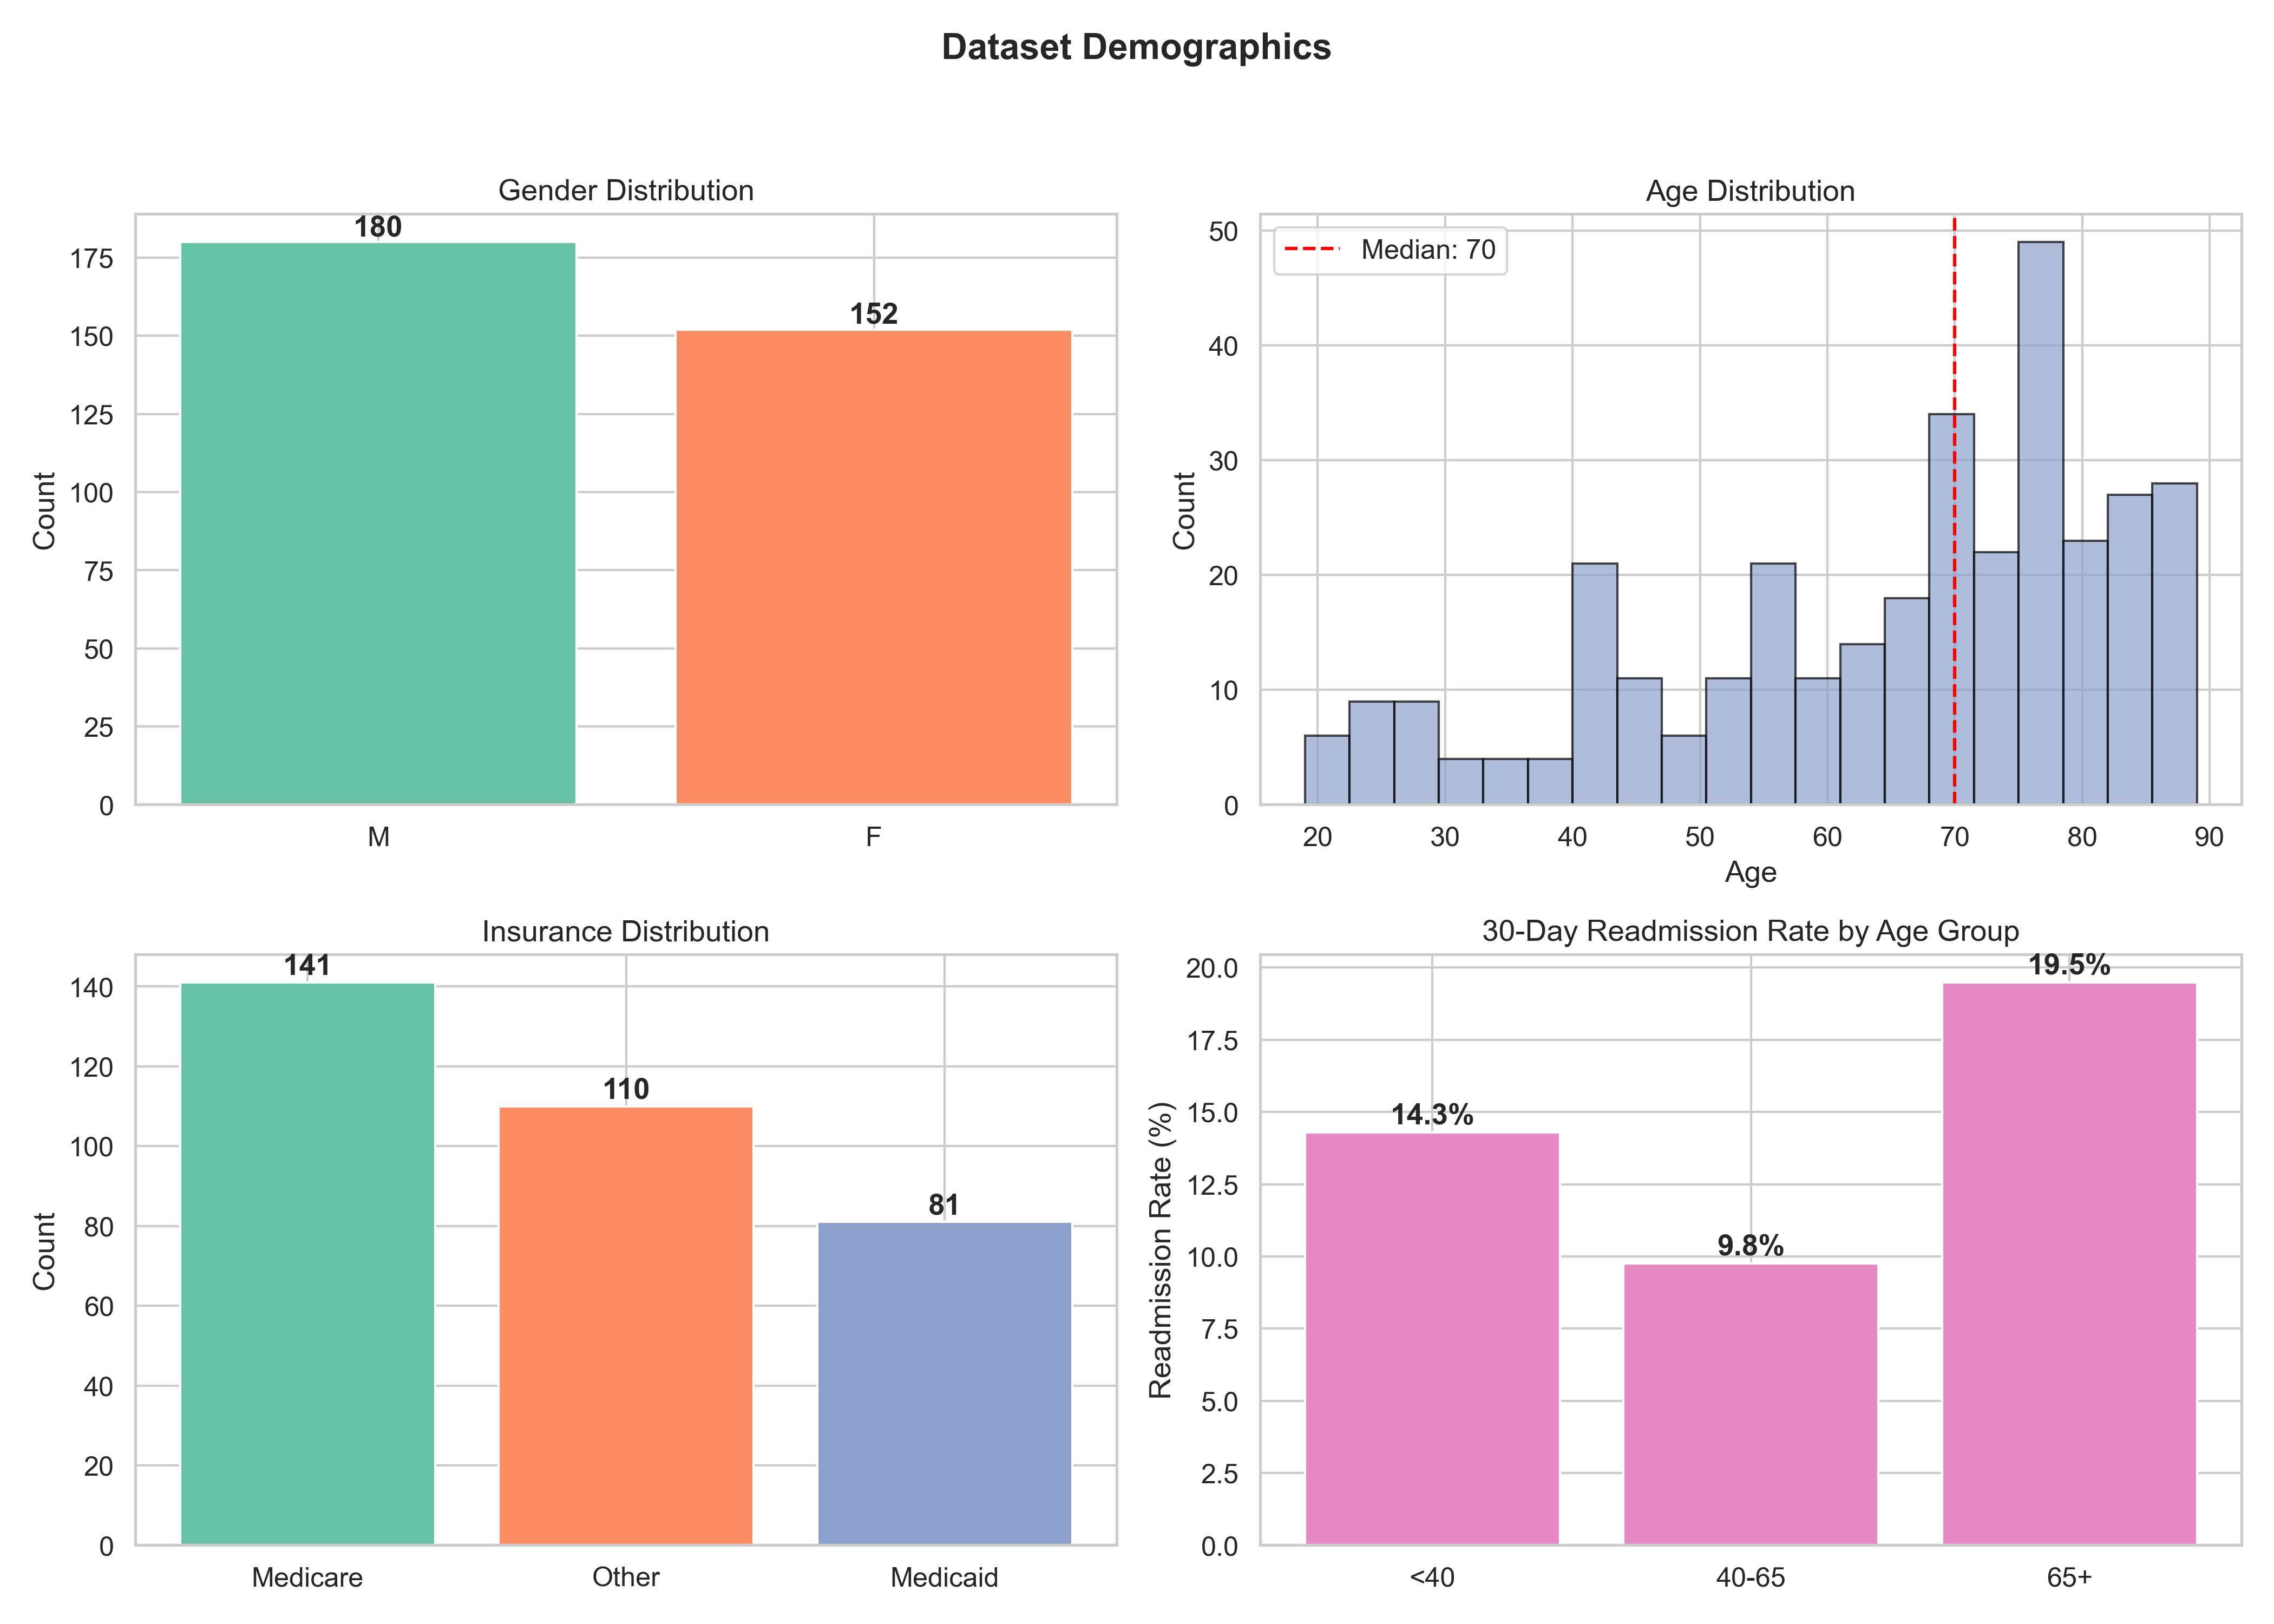


  Roc Curves


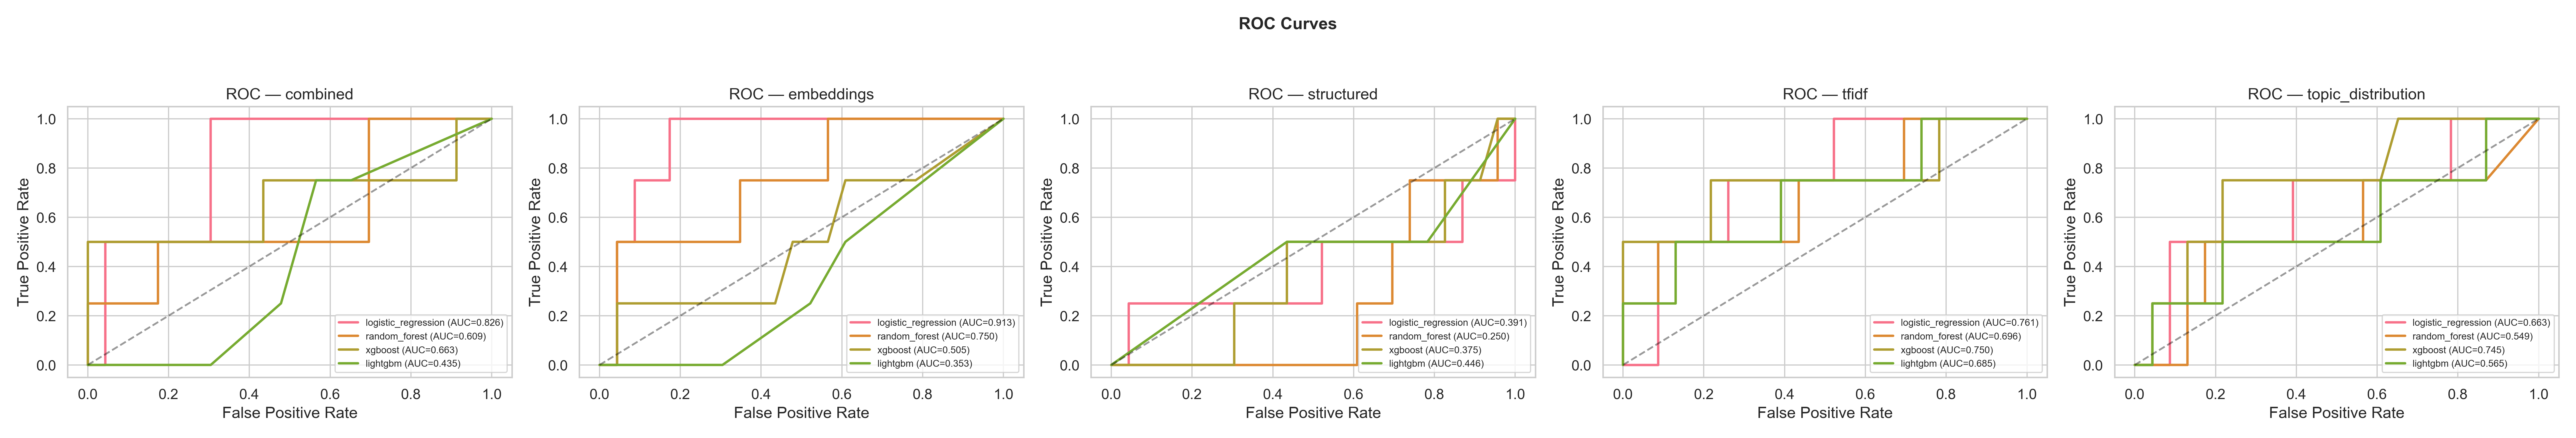


  Model Comparison


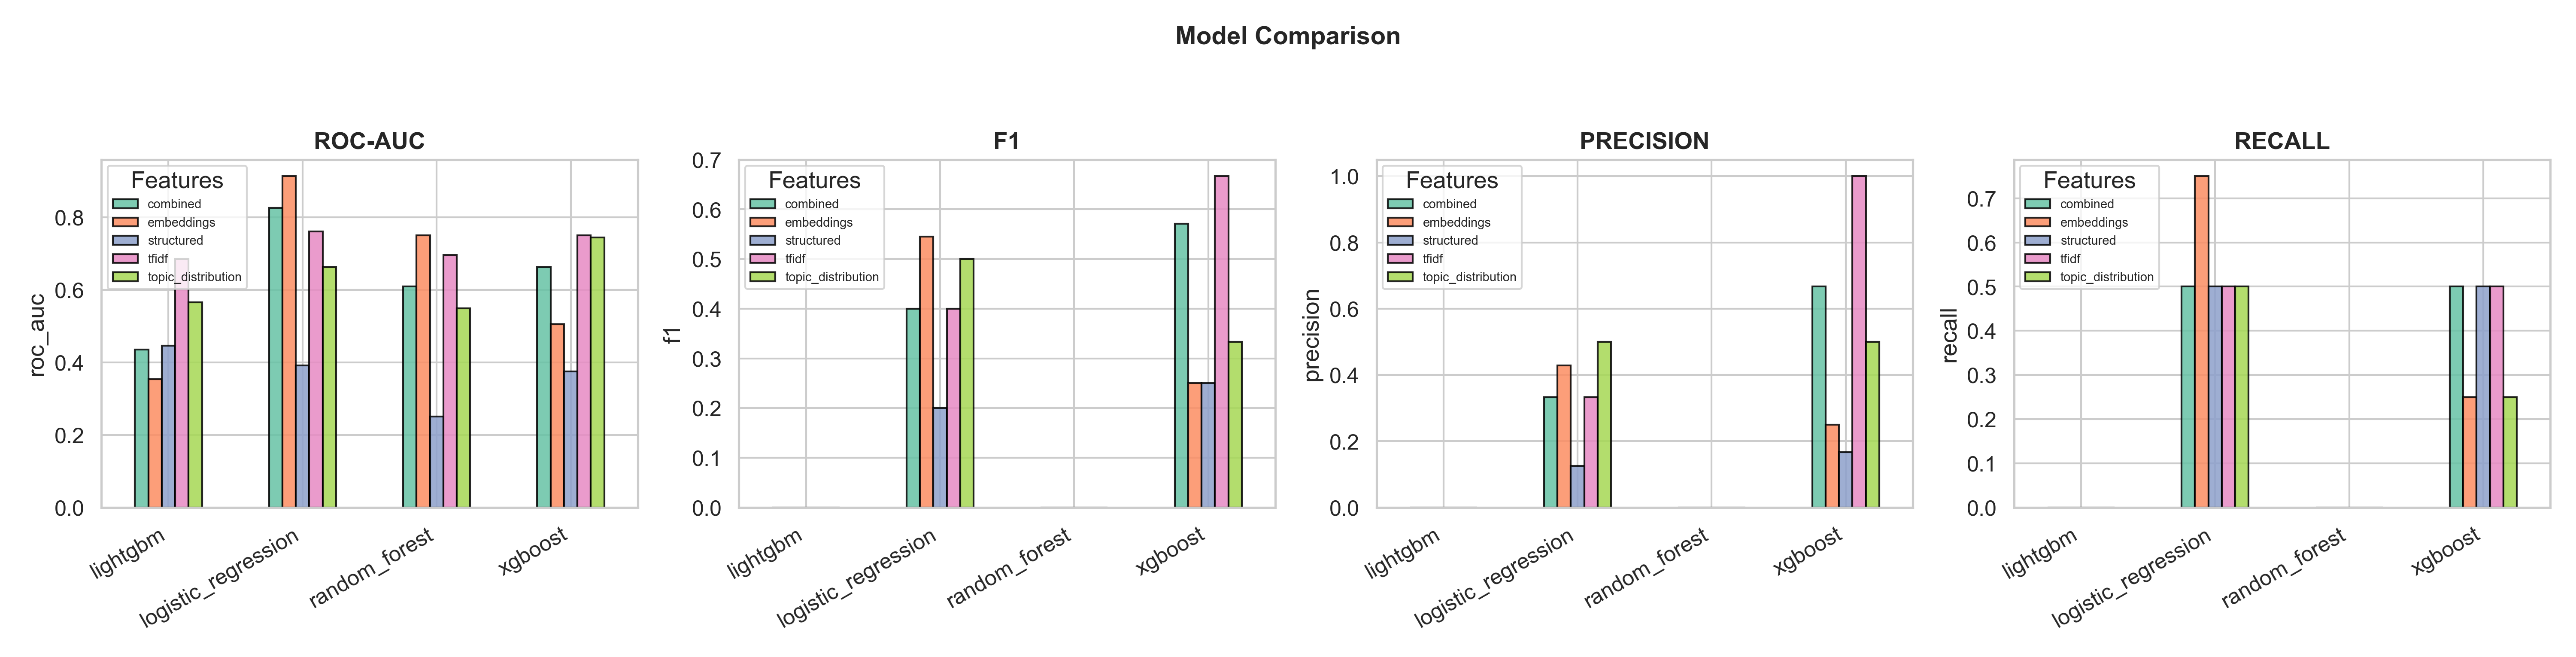


  Fairness Disparity


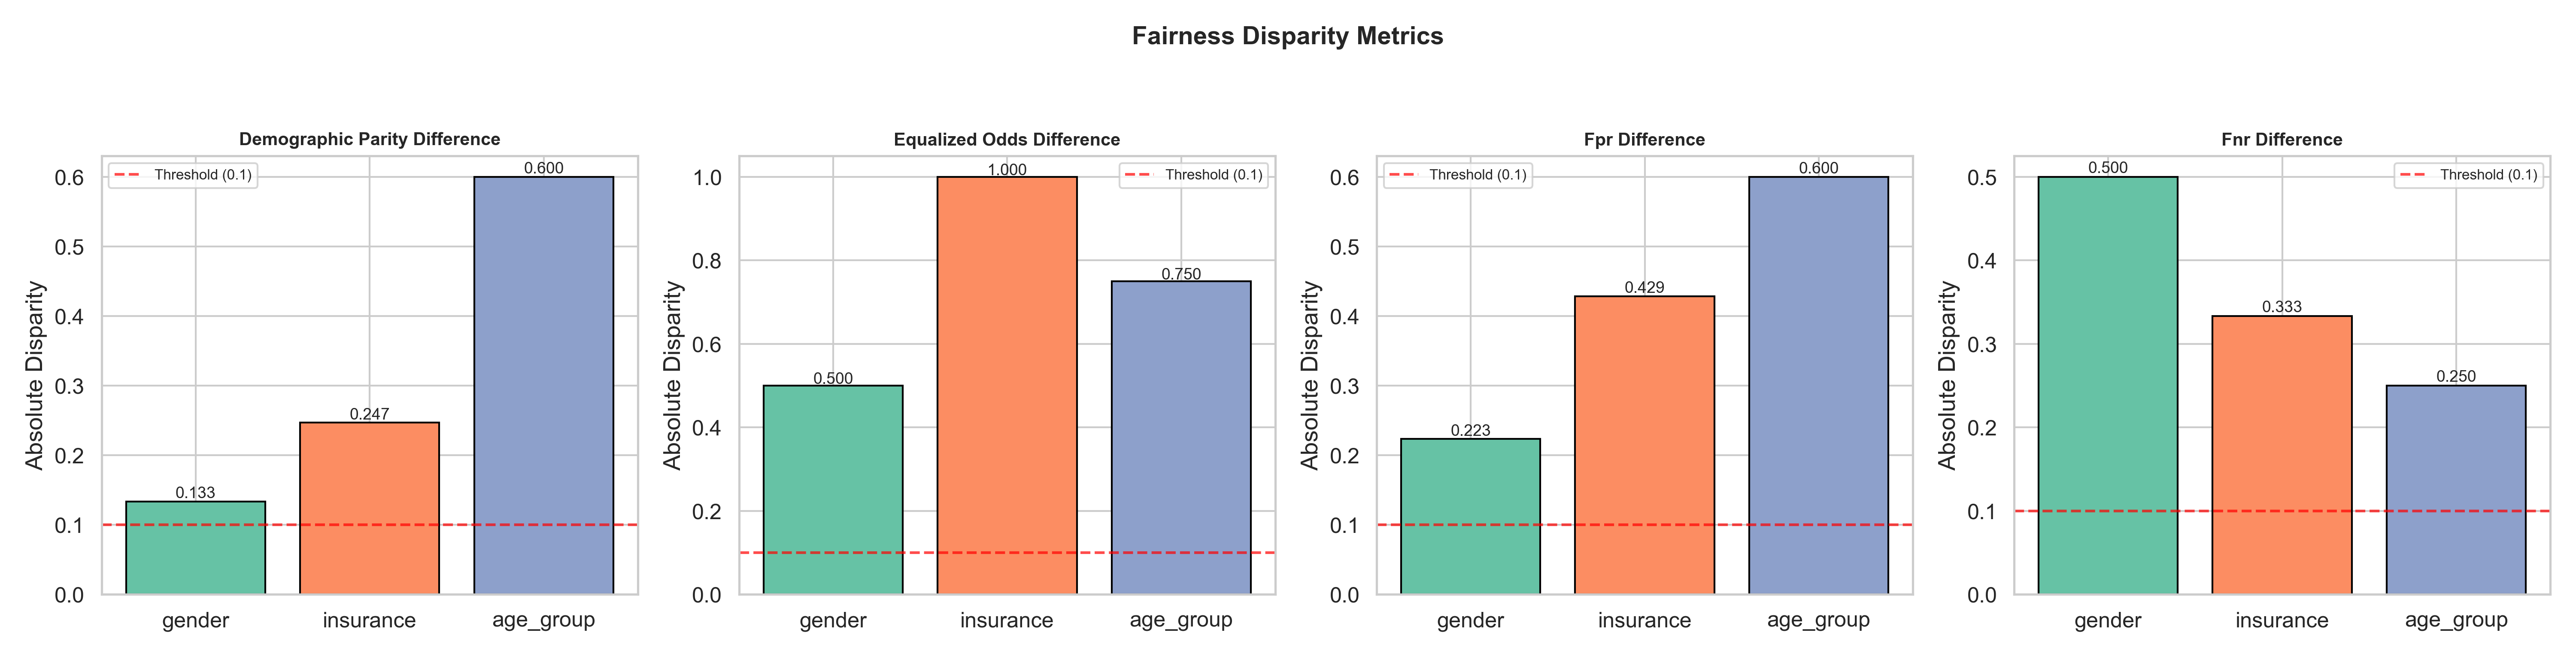

In [19]:
# Display key figures inline
from IPython.display import Image, display

key_figures = ["demographics", "roc_curves", "model_comparison", "fairness_disparity"]
for name in key_figures:
    fig_path = f"results/figures/{name}.png"
    if Path(fig_path).exists():
        print(f"\n{'='*60}")
        print(f"  {name.replace('_', ' ').title()}")
        print(f"{'='*60}")
        display(Image(filename=fig_path, width=800))

## 8. Export Dashboard Data

Serialize the pipeline outputs to `results/exports/*.json` so the FastAPI dashboard
serves real metrics instead of its mock fallback. Run the dashboard with:

```bash
uvicorn dashboard.backend.main:app --reload --port 8000
```


In [20]:
from src.exporter import export_dashboard_json

# Per-topic readmission rate needs the labels aligned with lda doc_topic_matrix
readmission_labels_for_topics = eligible_df["readmission_30day"].values.astype(int)

written = export_dashboard_json(
    prediction_results=prediction_results,
    fairness_results=fairness_results if "fairness_results" in dir() else None,
    lda_results=lda_results,
    readmission_labels=readmission_labels_for_topics,
    output_dir="results/exports",
)

print(f"Dashboard exports written:")
for section, path in written.items():
    print(f"  {section:10s} -> {path}")


2026-04-11 18:43:58,003 — INFO — Wrote results\exports\results.json (4837 bytes)
2026-04-11 18:43:58,007 — INFO — Wrote results\exports\fairness.json (2460 bytes)
2026-04-11 18:43:58,015 — INFO — Wrote results\exports\topics.json (19086 bytes)
2026-04-11 18:43:58,018 — INFO — Exported 3 dashboard file(s) to results\exports


Dashboard exports written:
  results    -> results\exports\results.json
  fairness   -> results\exports\fairness.json
  topics     -> results\exports\topics.json


## Summary

| Component | Details |
|-----------|---------|
| **Data** | Synthetic MIMIC-IV (200 patients, ~300+ notes) |
| **Preprocessing** | PHI removal, NLTK tokenization, clinical stopwords |
| **Embeddings** | ClinicalBERT (Bio_ClinicalBERT) with sliding-window chunking + PCA reduction |
| **Topic Modeling** | LDA with coherence-based topic selection + BERTopic (BioBERT + UMAP + HDBSCAN) |
| **Topic Analysis** | LDA vs BERTopic comparison, Mann-Whitney U topic-readmission association tests |
| **Features** | TF-IDF, clinical embeddings, topic distributions, structured, text stats, combined |
| **Models** | Logistic Regression, Random Forest, XGBoost, LightGBM |
| **Fairness** | Demographic parity, equalized odds, FPR/FNR disparity |
| **Output** | Publication-quality figures in  |